# Actor graph features: `bus14` vs `bus36_wcci_nomaint`

The GNN actor encoder is the only component that crosses grids in the
bus14 → WCCI transfer study. It reads graph node features **directly**, and with
`gnn_physical_scaling = false` those features are raw physical quantities.
`norm_obs = true` does not help here: it standardizes the *flat* observation,
which feeds the critic, on a separate code path from the graph.

So a transferred bus14 encoder is fed whatever distribution WCCI produces. This
notebook shows what that distribution looks like on both grids.

**Schema.** Measurements are on the **disaggregated line-node** graph
(`gnn_graph_type = "heterogeneous_line"`), which is what the transfer configs in
`configs/no_leakage_config/W_wcci_cas_hl_shared_transfer/` use. Two consequences
differ from the busbar graph:

1. Every node type shares one 12-column feature vector, so a channel is filled
   only on the type that owns it and zero-filled elsewhere. `p`/`theta` live on
   generator and load nodes; `rho` and the line state live on transmission-line
   nodes.
2. The nine **edge** channels are relation one-hots with no continuous content,
   so there is nothing to compare on edges. Everything below is nodes.

The configs also set `gnn_include_neighbors = false`, so every node is
controlled and `domain_mask` is constant at 1.

Data: 6000 do-nothing steps per environment, cap 300 per chronic, ~21 chronics
each. 426,000 node rows on bus14 and 1,236,000 on WCCI.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

TASK_DIR = Path.cwd()
while TASK_DIR.name != "Topology_Task" and TASK_DIR != TASK_DIR.parent:
    TASK_DIR = TASK_DIR.parent
sys.path.insert(0, str(TASK_DIR))

from common.feature_stats import compare_samples

DATA = TASK_DIR / "outputs" / "graph_feature_comparison" / "hl_raw"
CORR = TASK_DIR / "outputs" / "graph_feature_comparison" / "hl_corrected"
A, B = "bus14", "bus36_wcci_nomaint"
PMAX = {A: 140.0, B: 400.0}

samples = {e: dict(np.load(DATA / f"samples_{e}.npz")) for e in (A, B)}
corrected = {e: dict(np.load(CORR / f"samples_{e}.npz")) for e in (A, B)}
meta = json.loads((DATA / "meta.json").read_text())

# Which node type owns each measured channel.
OWNER = {
    "p": ("generator", "load"),
    "theta": ("generator", "load"),
    "theta_diff": ("transmission_line",),
    "rho": ("transmission_line",),
    "line_status": ("transmission_line",),
    "timestep_overflow": ("transmission_line",),
    "time_before_cooldown_line": ("transmission_line",),
    "time_before_cooldown_sub": ("busbar",),
}

def owning_rows(store, env, channel):
    """Boolean mask of the rows whose node type carries `channel`."""
    types = OWNER.get(channel)
    if types is None:
        return None
    mask = np.zeros_like(store[env]["node/is_busbar"], dtype=bool)
    for t in types:
        mask |= store[env][f"node/is_{t}"] > 0
    return mask

for env in (A, B):
    info = meta[env]
    print(f"{env}: {info['episodes']} episodes, {info['steps']} steps, "
          f"{info['n_node_rows']:,} node rows, {len(info['agents'])} agents")
print()
print("node features:", meta[A]["node_feature_names"])
print("edge features (relation one-hots only):", len(meta[A]["edge_feature_names"]))


bus14: 21 episodes, 6000 steps, 426,000 node rows, 3 agents
bus36_wcci_nomaint: 21 episodes, 6000 steps, 1,236,000 node rows, 4 agents

node features: ['is_busbar', 'is_generator', 'is_load', 'is_transmission_line', 'p', 'theta', 'line_status', 'rho', 'timestep_overflow', 'time_before_cooldown_line', 'time_before_cooldown_sub', 'domain_mask']
edge features (relation one-hots only): 9


## 1. What the encoder is looking at

The `bus` graph builder turns each Grid2Op observation into a graph whose
**nodes are busbars** (two per substation) and whose **edges are the physical
lines** between them. Each agent gets its own local subgraph — its substations
plus one hop of neighbours, since `gnn_include_neighbors = true` — and with
`share_actor_gnn = true` a single encoder processes all of them. That is why
this comparison pools every agent's nodes together: one set of weights sees all
of it.

Every busbar node carries the same 6-dimensional vector, every line edge the
same 4-dimensional one.

### Node features (`node_dim = 6`)

| feature | meaning | unit | dense? |
|---|---|---|---|
| `gen_p` | active power injected by generators attached to this busbar | MW | sparse — 0 where no generator |
| `gen_theta` | voltage angle at the generator connection | degrees | sparse — same nodes as `gen_p` |
| `load_p` | active power drawn by loads attached to this busbar | MW | sparse — 0 where no load |
| `load_theta` | voltage angle at the load connection | degrees | sparse — same nodes as `load_p` |
| `time_before_cooldown_sub` | steps until this substation may be reconfigured again | steps | 0 unless recently acted on |
| `domain_mask` | 1 if the node is one of this agent's own substations, 0 if it is a borrowed neighbour | indicator | dense |

### Edge features (`edge_dim = 4`)

| feature | meaning | unit | dense? |
|---|---|---|---|
| `line_status` | 1 connected, 0 disconnected | indicator | dense |
| `rho` | current flow ÷ thermal limit — the overload measure | per-unit | dense |
| `timestep_overflow` | consecutive steps this line has been over its limit | steps | ~always 0 |
| `time_before_cooldown_line` | steps until this line may be switched again | steps | 0 unless recently acted on |

`rho` is the one feature that is *already* dimensionless: it divides by each
grid's own thermal limits. Keep that in mind — it predicts which row of the
results below will look clean.

In [2]:
rows = []
for key in sorted(samples[A]):
    channel = key.split("/")[-1]
    x, y = samples[A][key], samples[B][key]
    rows.append({
        "feature": channel,
        f"zero%_{A}": round(100 * float(np.mean(x == 0)), 1),
        f"zero%_{B}": round(100 * float(np.mean(y == 0)), 1),
        f"range_{A}": f"[{x.min():.1f}, {x.max():.1f}]",
        f"range_{B}": f"[{y.min():.1f}, {y.max():.1f}]",
    })

width = max(len(r["feature"]) for r in rows)
print(f"{'feature':<{width}}{'zero% A':>9}{'zero% B':>9}   {'range A':<18}{'range B'}")
for r in rows:
    print(f"{r['feature']:<{width}}{r[f'zero%_{A}']:>9}{r[f'zero%_{B}']:>9}   "
          f"{r[f'range_{A}']:<18}{r[f'range_{B}']}")

print()
for env in (A, B):
    mix = {t: 100 * float(np.mean(samples[env][f"node/is_{t}"] > 0))
           for t in ("busbar", "generator", "load", "transmission_line")}
    print(f"{env:<22}" + "  ".join(f"{k}={v:.1f}%" for k, v in mix.items()))


feature                            zero% A  zero% B   range A           range B
relation_busbar_to_generator          94.7     93.8   [0.0, 1.0]        [0.0, 1.0]
relation_busbar_to_line_extremity     82.5     83.3   [0.0, 1.0]        [0.0, 1.0]
relation_busbar_to_line_origin        82.5     83.3   [0.0, 1.0]        [0.0, 1.0]
relation_busbar_to_load               90.4     89.5   [0.0, 1.0]        [0.0, 1.0]
relation_generator_to_busbar          94.7     93.8   [0.0, 1.0]        [0.0, 1.0]
relation_line_extremity_to_busbar     82.5     83.3   [0.0, 1.0]        [0.0, 1.0]
relation_line_origin_to_busbar        82.5     83.3   [0.0, 1.0]        [0.0, 1.0]
relation_load_to_busbar               90.4     89.5   [0.0, 1.0]        [0.0, 1.0]
relation_same_substation_busbar      100.0    100.0   [0.0, 0.0]        [0.0, 0.0]
domain_mask                            0.0      0.0   [1.0, 1.0]        [1.0, 1.0]
is_busbar                             60.6     65.0   [0.0, 1.0]        [0.0, 1.0]
is_gene

## 2. Shared columns make the aggregate misleading

Look at the zero columns. `p` and `theta` are zero on ~77% of rows and `rho` on
~63%. That is **not** sparsity in the physical sense — it is the shared feature
vector. Every node type carries all twelve columns, so a busbar row is zero in
every line-state column, a line row is zero in `p` and `theta`, and so on.

The node-type mix printed above shows why the fractions land where they do:
transmission-line nodes are ~36% of rows on both grids, generator and load nodes
together ~24% on bus14 and ~29% on WCCI.

So a mean and a standard deviation taken over *all* rows mostly describe how
many rows belong to other node types. Every channel below is therefore compared
twice: over all rows, and restricted to the node type that owns it.

Two things stand out from the ranges already:

- `p` spans **[0, 97] MW** on bus14 but **[−281, 399]** on WCCI. bus14 never
  produces a negative value; 7.8% of WCCI asset rows are negative.
- `theta` spans **[−11.6, 1.5]** degrees against **[−7.1, 16.8]** — displaced,
  not merely wider.


## 3. The four shift metrics

`compare_graph_features.py` reports four numbers per feature. They catch
different things, and reading only one of them is how you miss a problem:

- **`std_mean_shift`** — difference in means, in pooled standard deviations.
  Catches an *offset*. Blind to a change in spread.
- **`std_ratio`** — WCCI's standard deviation ÷ bus14's. Catches a change in
  *scale*. Blind to an offset.
- **`ks`** — Kolmogorov–Smirnov: the largest vertical gap between the two
  empirical CDFs, in [0, 1]. Sensitive to disagreement in the *bulk*, relatively
  insensitive to tails.
- **`w1_over_pooled_std`** — Wasserstein-1 distance in pooled standard
  deviations: how far mass has to travel to turn one distribution into the
  other. Unlike KS it does weigh the tails.

The pairing matters. A feature with `std_mean_shift ≈ 0` and `std_ratio ≈ 2.4`
is *not* fine — its centre matches while its spread does not, and KS looks
reassuringly small because the bulk still overlaps.

In [3]:
def show_metrics(store, title, restrict=False, scale=False):
    print(title)
    print(f"{'feature':<28}{'offset(sd)':>12}{'ratio':>9}{'ks':>8}{'w1(sd)':>9}")
    for channel in ("p", "theta", "theta_diff", "rho", "line_status",
                    "timestep_overflow"):
        key = f"node/{channel}"
        if key not in store[A]:
            continue
        va, vb = store[A][key], store[B][key]
        if restrict:
            ma, mb = owning_rows(store, A, channel), owning_rows(store, B, channel)
            if ma is None:
                continue
            va, vb = va[ma], vb[mb]
        if scale:
            if channel == "p":
                va, vb = va / PMAX[A], vb / PMAX[B]
            elif channel in ("theta", "theta_diff"):
                va, vb = va / 180.0, vb / 180.0
        r = compare_samples({key: va}, {key: vb}, A, B)[0]
        if not np.isfinite(r["ks"]):
            continue
        print(f"{channel:<28}{r['std_mean_shift']:>12.3f}{r['std_ratio']:>9.3f}"
              f"{r['ks']:>8.3f}{r['w1_over_pooled_std']:>9.3f}")
    print()

show_metrics(samples, "All sampled rows")
show_metrics(samples, "Restricted to the owning node type", restrict=True)


All sampled rows
feature                       offset(sd)    ratio      ks   w1(sd)


p                                 -0.037    2.141   0.042    0.204


theta                              0.653    0.827   0.157    0.653


rho                               -0.088    0.922   0.053    0.088


line_status                       -0.005    0.999   0.002    0.004
timestep_overflow                 -0.002    0.695   0.000    0.000

Restricted to the owning node type
feature                       offset(sd)    ratio      ks   w1(sd)
p                                 -0.158    2.541   0.201    0.485


theta                              1.864    1.430   0.678    1.864


rho                               -0.260    1.050   0.141    0.261
line_status                       -0.034      nan   0.001    0.060
timestep_overflow                 -0.004    0.697   0.000    0.000



### The same channels, restricted to the node type that owns them

Dropping the rows of other node types gives the distribution the encoder sees
*where the quantity actually exists*. This is the comparison the weights respond
to.


In [4]:
for channel in ("p", "theta", "rho"):
    key = f"node/{channel}"
    x = samples[A][key][owning_rows(samples, A, channel)]
    y = samples[B][key][owning_rows(samples, B, channel)]
    print(f"{channel:<8} {A}: mean={x.mean():8.2f} std={x.std():7.2f}   "
          f"{B}: mean={y.mean():8.2f} std={y.std():7.2f}   "
          f"std ratio={y.std() / x.std():.2f}   rows={x.size:,}/{y.size:,}")


p        bus14: mean=   27.31 std=  27.00   bus36_wcci_nomaint: mean=   19.07 std=  68.61   std ratio=2.54   rows=102,000/354,000
theta    bus14: mean=   -5.16 std=   2.71   bus36_wcci_nomaint: mean=    1.06 std=   3.87   std ratio=1.43   rows=102,000/354,000
rho      bus14: mean=    0.36 std=   0.17   bus36_wcci_nomaint: mean=    0.32 std=   0.18   std ratio=1.05   rows=156,000/450,000


Restricting to the owning type sharpens every measured channel:

| feature | KS (all rows) | KS (owning type) | ratio (all) | ratio (owning) |
|---|---|---|---|---|
| `theta` | 0.157 | **0.678** | 0.83 | 1.43 |
| `p` | 0.042 | 0.201 | 2.14 | **2.54** |
| `rho` | 0.053 | 0.141 | 0.92 | 1.05 |

`theta` is the problem channel: KS 0.678 with **+1.86 sd** of displacement.
bus14 averages −5.16° on asset nodes, WCCI +1.06°.

`p` is a width problem rather than a displacement: means −0.16 sd apart but
spreads 27.0 vs 68.6.

`rho` needs nothing — ratio 1.05, offset −0.26. These are the *same values the
busbar graph gives*, which is the point: it is the same set of lines carrying
the same loadings, and `rho` is already per-unit.


## 4. The distributions

### Dense features first

`rho` and `domain_mask` exist on every edge/node, so they need no conditioning.

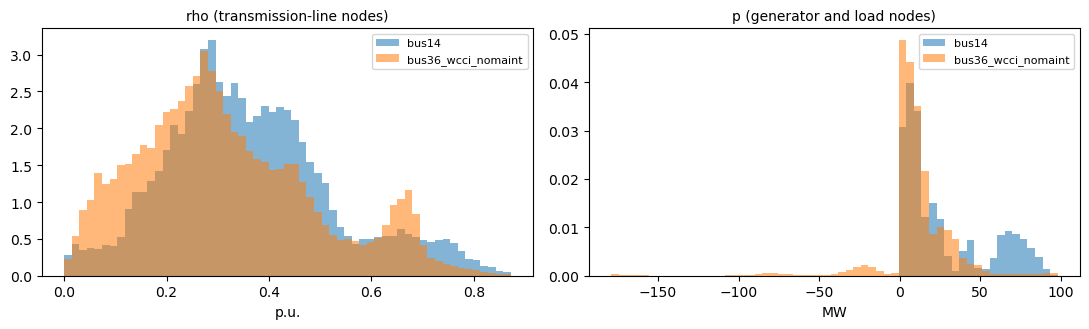

In [5]:
def overlay(ax, title, values_a, values_b, clip=(0.001, 0.999), bins=60):
    combined = np.concatenate([values_a, values_b])
    low, high = np.quantile(combined, clip)
    if high <= low:
        low, high = combined.min(), combined.max() + 1e-6
    edges = np.linspace(low, high, bins)
    ax.hist(values_a, bins=edges, density=True, alpha=0.55, label=A)
    ax.hist(values_b, bins=edges, density=True, alpha=0.55, label=B)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

def owning(store, env, channel):
    return store[env][f"node/{channel}"][owning_rows(store, env, channel)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
overlay(axes[0], "rho (transmission-line nodes)",
        owning(samples, A, "rho"), owning(samples, B, "rho"), clip=(0.0, 0.999))
axes[0].set_xlabel("p.u.")
overlay(axes[1], "p (generator and load nodes)",
        owning(samples, A, "p"), owning(samples, B, "p"), clip=(0.01, 0.96))
axes[1].set_xlabel("MW")
fig.tight_layout()
plt.show()


`rho` lands almost on top of itself: both grids sit mostly in the 0.2–0.5 band
with a thin tail toward 1.0, `std_ratio = 1.05`. This is what a feature that
needs no rescaling looks like, and it is no accident — `rho` is already
normalized by each grid's own thermal limits.

`p` shares a centre but not a width, and only WCCI goes negative.

### Voltage angles


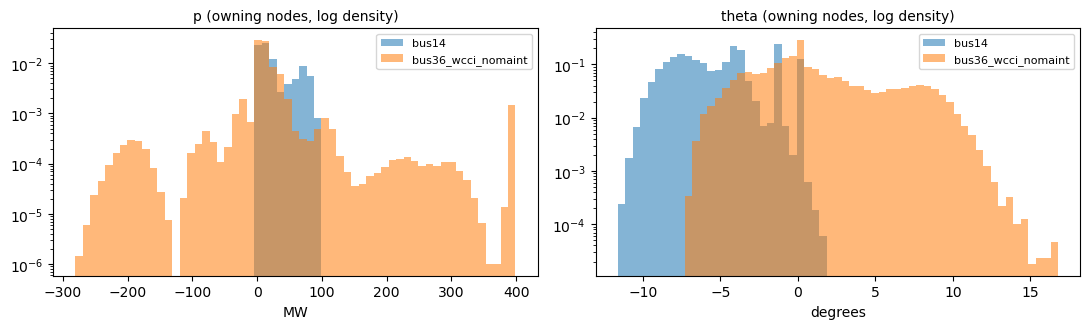

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
overlay(axes[0], "p (owning nodes, log density)",
        owning(samples, A, "p"), owning(samples, B, "p"), clip=(0.0, 1.0))
axes[0].set_yscale("log"); axes[0].set_xlabel("MW")
overlay(axes[1], "theta (owning nodes, log density)",
        owning(samples, A, "theta"), owning(samples, B, "theta"), clip=(0.0, 1.0))
axes[1].set_yscale("log"); axes[1].set_xlabel("degrees")
fig.tight_layout()
plt.show()


The log-density view shows the tails. WCCI carries a generator pinned near its
399 MW rating and a load region reaching −281 MW, neither of which occurs
anywhere on bus14. A transferred encoder has no calibration for either.

Its first layer is `Linear(12 → 128)`, so an input four times larger produces a
proportionally larger pre-activation on every unit reading that channel.

### The angle is the binding problem


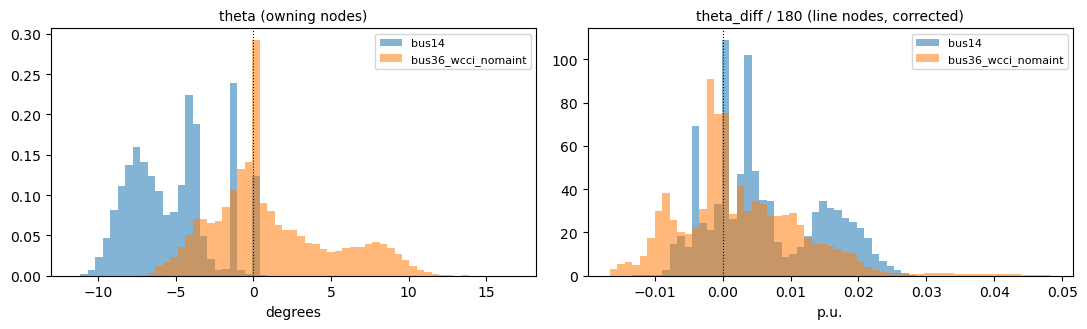

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
overlay(axes[0], "theta (owning nodes)",
        owning(samples, A, "theta"), owning(samples, B, "theta"), clip=(0.0, 1.0))
axes[0].axvline(0.0, color="k", lw=0.8, ls=":"); axes[0].set_xlabel("degrees")
overlay(axes[1], "theta_diff / 180 (line nodes, corrected)",
        owning(corrected, A, "theta_diff") / 180.0,
        owning(corrected, B, "theta_diff") / 180.0, clip=(0.001, 0.999))
axes[1].axvline(0.0, color="k", lw=0.8, ls=":"); axes[1].set_xlabel("p.u.")
fig.tight_layout()
plt.show()


bus14's angles live almost entirely on the negative side, WCCI's spread across
both signs. The distributions are *displaced*, not merely rescaled.

The distinction is practical. The configs set `gnn_node_pre_encoder = true` and
`gnn_layer_norm = true`, so the node pre-encoder is `Linear → ReLU → LayerNorm`.
LayerNorm largely absorbs a uniform change of *scale* — which is why `p`, bad as
it looks, is partly self-correcting. It does **not** absorb an *offset*:
shifting every angle by a constant moves pre-activations to a different part of
the ReLU, and that survives normalization.

The right panel is the fix: `theta_diff`, the angle drop along each line, is
gauge-invariant and lands at ratio 1.15, KS 0.230.


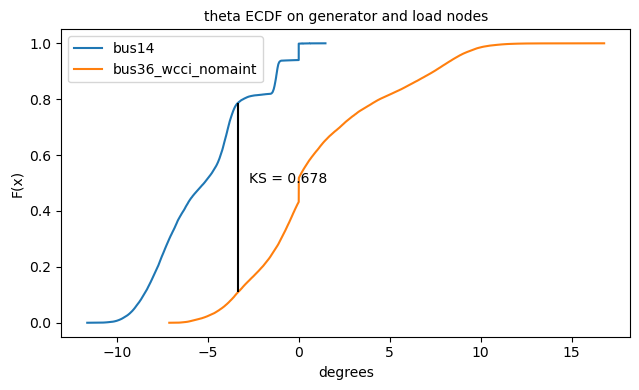

In [8]:
def ecdf(values):
    ordered = np.sort(values)
    return ordered, np.arange(1, ordered.size + 1) / ordered.size

fig, ax = plt.subplots(figsize=(6.5, 4))
x, fx = ecdf(owning(samples, A, "theta"))
y, fy = ecdf(owning(samples, B, "theta"))
ax.plot(x, fx, label=A)
ax.plot(y, fy, label=B)

grid = np.linspace(min(x[0], y[0]), max(x[-1], y[-1]), 2000)
gap = np.abs(np.interp(grid, x, fx) - np.interp(grid, y, fy))
i = int(gap.argmax())
ax.vlines(grid[i], np.interp(grid[i], x, fx), np.interp(grid[i], y, fy),
          color="k", lw=1.5)
ax.annotate(f"KS = {gap[i]:.3f}", (grid[i], 0.5),
            textcoords="offset points", xytext=(8, 0))
ax.set_xlabel("degrees"); ax.set_ylabel("F(x)")
ax.set_title("theta ECDF on generator and load nodes", fontsize=10)
ax.legend()
fig.tight_layout()
plt.show()


## 5. Two failure modes, one chart

Plotting offset against scale separates the features that are fine from the two
different ways the others are not.

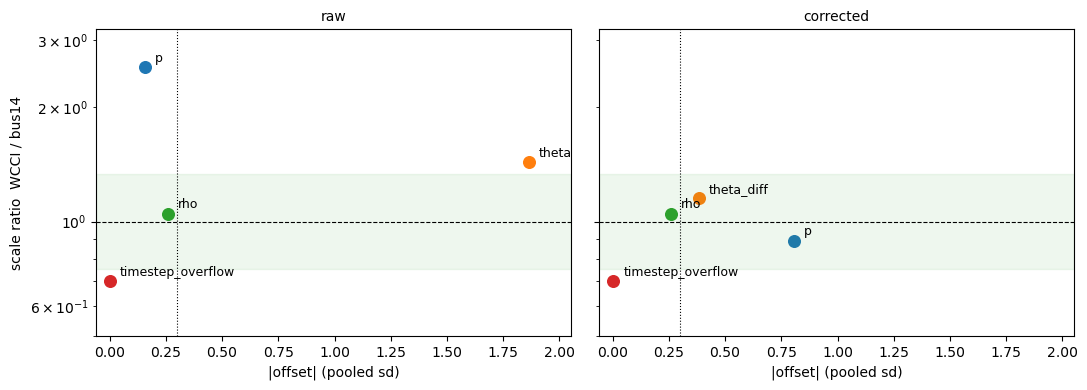

In [9]:
finite = []
for store, scaled, tag in ((samples, False, "raw"), (corrected, True, "corrected")):
    for channel in ("p", "theta", "theta_diff", "rho", "timestep_overflow"):
        key = f"node/{channel}"
        if key not in store[A]:
            continue
        ma, mb = owning_rows(store, A, channel), owning_rows(store, B, channel)
        va, vb = store[A][key][ma], store[B][key][mb]
        if scaled:
            if channel == "p":
                va, vb = va / PMAX[A], vb / PMAX[B]
            elif channel in ("theta", "theta_diff"):
                va, vb = va / 180.0, vb / 180.0
        r = compare_samples({key: va}, {key: vb}, A, B)[0]
        if np.isfinite(r["std_ratio"]) and np.isfinite(r["std_mean_shift"]):
            finite.append((tag, channel, abs(r["std_mean_shift"]), r["std_ratio"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, tag in zip(axes, ("raw", "corrected")):
    for t, name, x, y in finite:
        if t != tag:
            continue
        ax.scatter(x, y, s=70)
        ax.annotate(name, (x, y), textcoords="offset points", xytext=(7, 4),
                    fontsize=9)
    ax.axhline(1.0, color="k", lw=0.8, ls="--")
    ax.axvline(0.3, color="k", lw=0.8, ls=":")
    ax.axhspan(1 / 1.33, 1.33, color="tab:green", alpha=0.08)
    ax.set_yscale("log"); ax.set_ylim(0.5, 3.2); ax.set_xlim(-0.06, 2.05)
    ax.set_xlabel("|offset| (pooled sd)")
    ax.set_title(tag, fontsize=10)
axes[0].set_ylabel("scale ratio  WCCI / bus14")
fig.tight_layout()
plt.show()


## 6. What this means for the transfer runs

**`rho` transfers as is.** Dimensionless by construction, `std_ratio = 1.05`.
The most decision-relevant channel needs no help.

**`p` is a scale problem.** Means agree within 0.16 sd while spreads differ
2.54× on the nodes that carry it. LayerNorm after the node pre-encoder absorbs
much of a uniform rescaling, so this is the milder of the two issues — but the
negative WCCI region (7.8% of asset rows, down to −281 MW) is genuinely unseen
territory, not a bigger version of something familiar.

**`theta` is an offset problem, and that is the one to fix.** On the nodes that
carry it, KS 0.678 with **+1.86 sd** of displacement. Offsets are exactly what
LayerNorm does not remove.

### Which knob

`gnn_running_norm = true` standardizes per environment and per node type over
`p` and `theta`. It is the only mechanism that can move a displaced channel, and
it deliberately excludes `rho`.

**It was measured and rejected.** Standardizing each grid with its own
statistics aligns the aggregate moments exactly and then makes both channels
*much* worse:

| channel | KS raw | KS standardized | "not this type" encodes as |
|---|---|---|---|
| `p` | 0.042 | **0.773** | −0.371 vs −0.145 |
| `theta` | 0.157 | **0.673** | +0.481 vs −0.143 |

The cause is the shared feature vector. Each channel is a point mass at zero
contributed by the three node types that do not own it, plus the measurement of
the one that does. Subtracting a per-grid mean moves that point mass to a
grid-dependent location, so the encoder's most frequent input stops meaning the
same thing on the two grids. On `theta` the sign even flips.

Standardization is also scale-invariant (it erases any scaling applied before
it) and its statistics drift during training, while a transferred encoder needs
a fixed input scale.

### What was adopted instead

- `gnn_physical_scaling = true` — divides `p` by each grid's maximum `gen_pmax`
  (140 vs 400 MW). Multiplicative, so zeros stay at zero; fixed at construction,
  so it does not drift. Brings the `p` spread ratio from 2.54 to 0.89.
- `gnn_angle_representation = edge_diff` — replaces the absolute angle with the
  drop along each line, carried on the line node. Gauge-invariant, so the
  displacement disappears: ratio 1.15, KS 0.230.

**But scaling is an exchange, not a repair.** Dividing each grid by its own
constant is not offset-preserving: bus14 runs its generators at 39% of its fleet
maximum against WCCI's 20%, so `p`'s offset grows from −0.158 to −0.808 and its
KS from 0.201 to 0.511. The worst displacement across all channels still falls
(1.86 → 0.81) and every ratio ends inside the band, so the trade is favourable —
but the transfer runs deliberately include both input conditions so the question
can be settled empirically rather than argued.

Corrected samples are in `outputs/graph_feature_comparison/hl_corrected`.

### One caveat on the constant rows

`line_status`, the two cooldowns and `timestep_overflow` are constant or nearly
so in this sample. Partly that is do-nothing never triggering a cooldown, and
partly that only active line rows are informative. Those rows say nothing about
how the two grids compare.
